# 🧪Lab: Predicting Seismic Building Response with Support Vector Regression

In this lab, you will practice **Support Vector Machine (SVM)** in the context of **regression**. Over the past two weeks, we have focused on SVM for **classification problems**. However, SVM can also be extended to handle **regression tasks**—this is known as **Support Vector Regression (SVR)**.

To explore this, you will work with the following paper:  https://www.nature.com/articles/s41598-024-81705-3

In this paper, the authors use **real seismic monitoring data** to develop an SVR-based model for predicting the **maximum inter-story drift ratio** of buildings during earthquakes. The authors compare a full-feature model with a reduced-feature version, and demonstrate that SVR is effective in this complex, real-world regression setting.

You will begin by reading the **introduction** of the paper to understand the motivation behind the problem. Later, you will apply Support Vector Regression to their dataset.

Reference:

- Tao, D., Fang, S., Liu, H. et al. Support vector regression model for the prediction of buildings’ maximum seismic response based on real monitoring data. Sci Rep 14, 29874 (2024). https://doi.org/10.1038/s41598-024-81705-3

--- 

**Software**: Use `scikit-learn` and its implementation of Support Vector Regression in this lab. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

--- 

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [ ]:
NAME(s) = "Max", "Michelle", "Kaven"

## 1. Paper reflection (10 points)

a. After reading the introduction of the paper, discuss within the group and address the following questions:
   
   - Why is predicting seismic building response important? (You may consider implications for human safety, economic losses, emergency planning, etc)

- Why might the dataset of this study be particularly well-suited for a machine learning approach? (You may think about the volume and diversity of data, the types of features provided, and the limitations of traditional physics-based methods).

Please, elaborate on your answers.

**ANSWER:**

Predicting the seismic building response is important because earthquakes can cause serious damage, injuries, deaths, etc. By being able to quickly estimate how strongly a building may respond to an earthquake, one can help identify buildings that need inspection or attention and aim to prevent further loss. Additionally, this can help make decisions about safety, repairs, and economic losses.

The dataset in this study is good for machine learning because it contains a large number of observations from real earthquakes and many different types of predictors. These predictors include building characteristics, earthquake characteristics, spectral measurements, and duration measurements, which give a machine learning model lots of variables to learn relationships with building response. Machine learning is also helpful because it is able to map complex and nonlinear relationships, which may be the case here. Traditional approaches can require a lot of information and computational work, whereas machine learning is able to make practical predictions quickly for many buildings.

b. After reading the paper, explain, in your own words, how Support Vector Regression (SVR) works. In addition, explain Formulas (1) to (11) from the paper, specifically, what is the intuition behind each equation in light of what we covered in class regarding Support Vector Machine, so you can see the correspondence between SVM for classification and regression.

**ANSWER:**

Support Vector Regression uses the same general ideas as Support Vector Machines for classification, but instead of separating observations into classes, it predicts a continuous value. SVR tries to find a regression function with an epsilon-sized region around it where small prediction errors are allowed without being penalized. Observations outside this region contribute to the error, while the observations that influence the final regression function become the support vectors. The parameter \(C\) controls how strongly the model penalizes observations outside the allowed region, and kernels allow the model to capture nonlinear relationships between the predictors and the response.

Formula (1) defines the epsilon region around the regression function. It says that the difference between the predicted and actual value should be no greater than \(\epsilon\). This is similar to the margin in SVM classification, except in SVR the goal is for observations to fall inside a tube around the prediction function.

Formula (2) shows the basic goal of balancing prediction error with model complexity. The model tries to reduce errors while also keeping the weights small, which encourages a simpler regression function.

Formula (3) defines the epsilon-insensitive error. If a prediction is within \(\epsilon\) of the actual value, there is no error penalty. If it falls outside that region, the amount beyond the allowed error is penalized.

Formula (4) introduces the slack variables and the penalty parameter \(C\). The model tries to keep the regression function simple while also minimizing violations outside the epsilon region. A larger \(C\) places a greater penalty on these violations.

Formula (5) gives the constraints involving the slack variables. The two slack variables represent how far an observation falls outside either the upper or lower side of the epsilon tube.

Formula (6) rewrites the optimization problem using a Lagrangian and Lagrange multipliers. This is similar to the process used with SVM classification and makes it possible to solve the constrained optimization problem.

Formula (7) shows that the weight vector can be written as a combination of the transformed training observations and their Lagrange multipliers. Observations with nonzero multipliers are the ones that affect the final regression function.

Formula (8) requires the differences between the two sets of Lagrange multipliers to sum to zero. This is one of the conditions that results from solving the optimization problem.

Formula (9) connects the Lagrange multipliers to \(C\), limiting how much influence an individual observation can have on the model.

Formula (10) shows how the intercept \(b\) can be calculated from a support vector. It also introduces the kernel function, which allows SVR to model nonlinear relationships without explicitly calculating the transformed feature space.

Formula (11) is the final prediction function. The predicted value is based on the support vectors, their coefficients, the kernel function, and the intercept. Similar to SVM classification, the support vectors are the observations that directly determine the final model.

## 2. Exploratory Analysis (15 Points)

a. Load the dataset accompanying this lab and create a new dataset containing the same input features used as predictors in the paper, along with the target variable, *Drift*. **You will use only this new dataset throughout the remainder of the lab.** Display the first few rows of the resulting dataset.

*Hint*: The exact input features used in the predictive framework are clearly specified in the paper. You may also refer to Table 3 to help identify the corresponding features in the provided dataset.

In [3]:
import pandas as pd
raw_df = pd.read_excel('data_lab02.xlsx', header=1)

cols_to_drop = [
    'Network',
    'Building ID',
    'Soil info',
    'Vs30',
    'Event Date',
    'Typology',
    'PTV',
    'PTA',
    'PTD'
]

target = "Drift"

cols_present_to_drop = [
    c for c in raw_df.columns
    if any(drop.lower() in str(c).lower() for drop in cols_to_drop)
]

df = raw_df.drop(columns=cols_present_to_drop)
df = df.apply(pd.to_numeric, errors='coerce').dropna()
df.head()

,B_Lat.,B_Long.,Height,No. of story,E_Lat.,E_Long.,Magnitude,Epicentral distance (R),PGA,PGV,...,Uniform [0.15g],Bracketed [0.2g],Uniform [0.2g],Significant_a1 [(5-75)%],Significant_a2 [(5-95)%],Significant_v1 [(5-75)%],Significant_v2 [(5-95)%],Significant_d1 [(5-75)%],Significant_d2 [(5-95)%],ZX
1,36.132,140.073,3400.0,8.0,34.0300,136.2283,5.3,420.7,1.577005,0.073452,...,0.0,0.0,0.0,54.89,73.15,56.97,81.65,93.23,122.20,54.300537
2,36.132,140.073,3400.0,8.0,36.1067,139.8917,3.8,16.6,3.449968,0.132411,...,0.0,0.0,0.0,5.96,19.57,13.88,27.74,25.26,63.18,6.934593
3,36.132,140.073,3400.0,8.0,37.0200,141.0583,4.2,132.2,0.854165,0.036735,...,0.0,0.0,0.0,10.60,29.11,18.58,48.81,70.65,72.53,5.923775
4,36.132,140.073,3400.0,8.0,36.0450,140.0867,3.4,9.8,0.549761,0.026009,...,0.0,0.0,0.0,10.45,25.24,13.61,32.37,33.76,57.79,5.139623
5,36.132,140.073,3400.0,8.0,35.4600,140.7517,5.7,96.6,5.863478,1.006804,...,0.0,0.0,0.0,24.25,48.01,23.06,50.12,28.47,70.65,20.686939


In [4]:
df.shape
df.info()

<class 'pandas.DataFrame'>
Index: 11916 entries, 1 to 12503
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   B_Lat.                    11916 non-null  float64
 1   B_Long.                   11916 non-null  float64
 2   Height                    11916 non-null  float64
 3   No. of story              11916 non-null  float64
 4   E_Lat.                    11916 non-null  float64
 5   E_Long.                   11916 non-null  float64
 6   Magnitude                 11916 non-null  float64
 7   Epicentral distance (R)   11916 non-null  float64
 8   PGA                       11916 non-null  float64
 9   PGV                       11916 non-null  float64
 10  PGD                       11916 non-null  float64
 11  AI                        11916 non-null  float64
 12  DP                        11916 non-null  float64
 13  CAV                       11916 non-null  float64
 14  SA1                   

b. Explore the distribution of the target variable (Drift), and create scatterplots between Drift and input features.

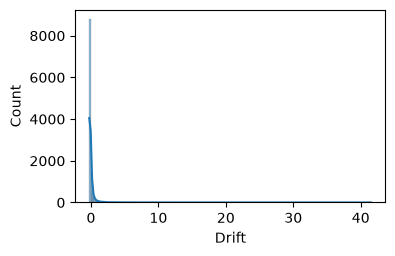

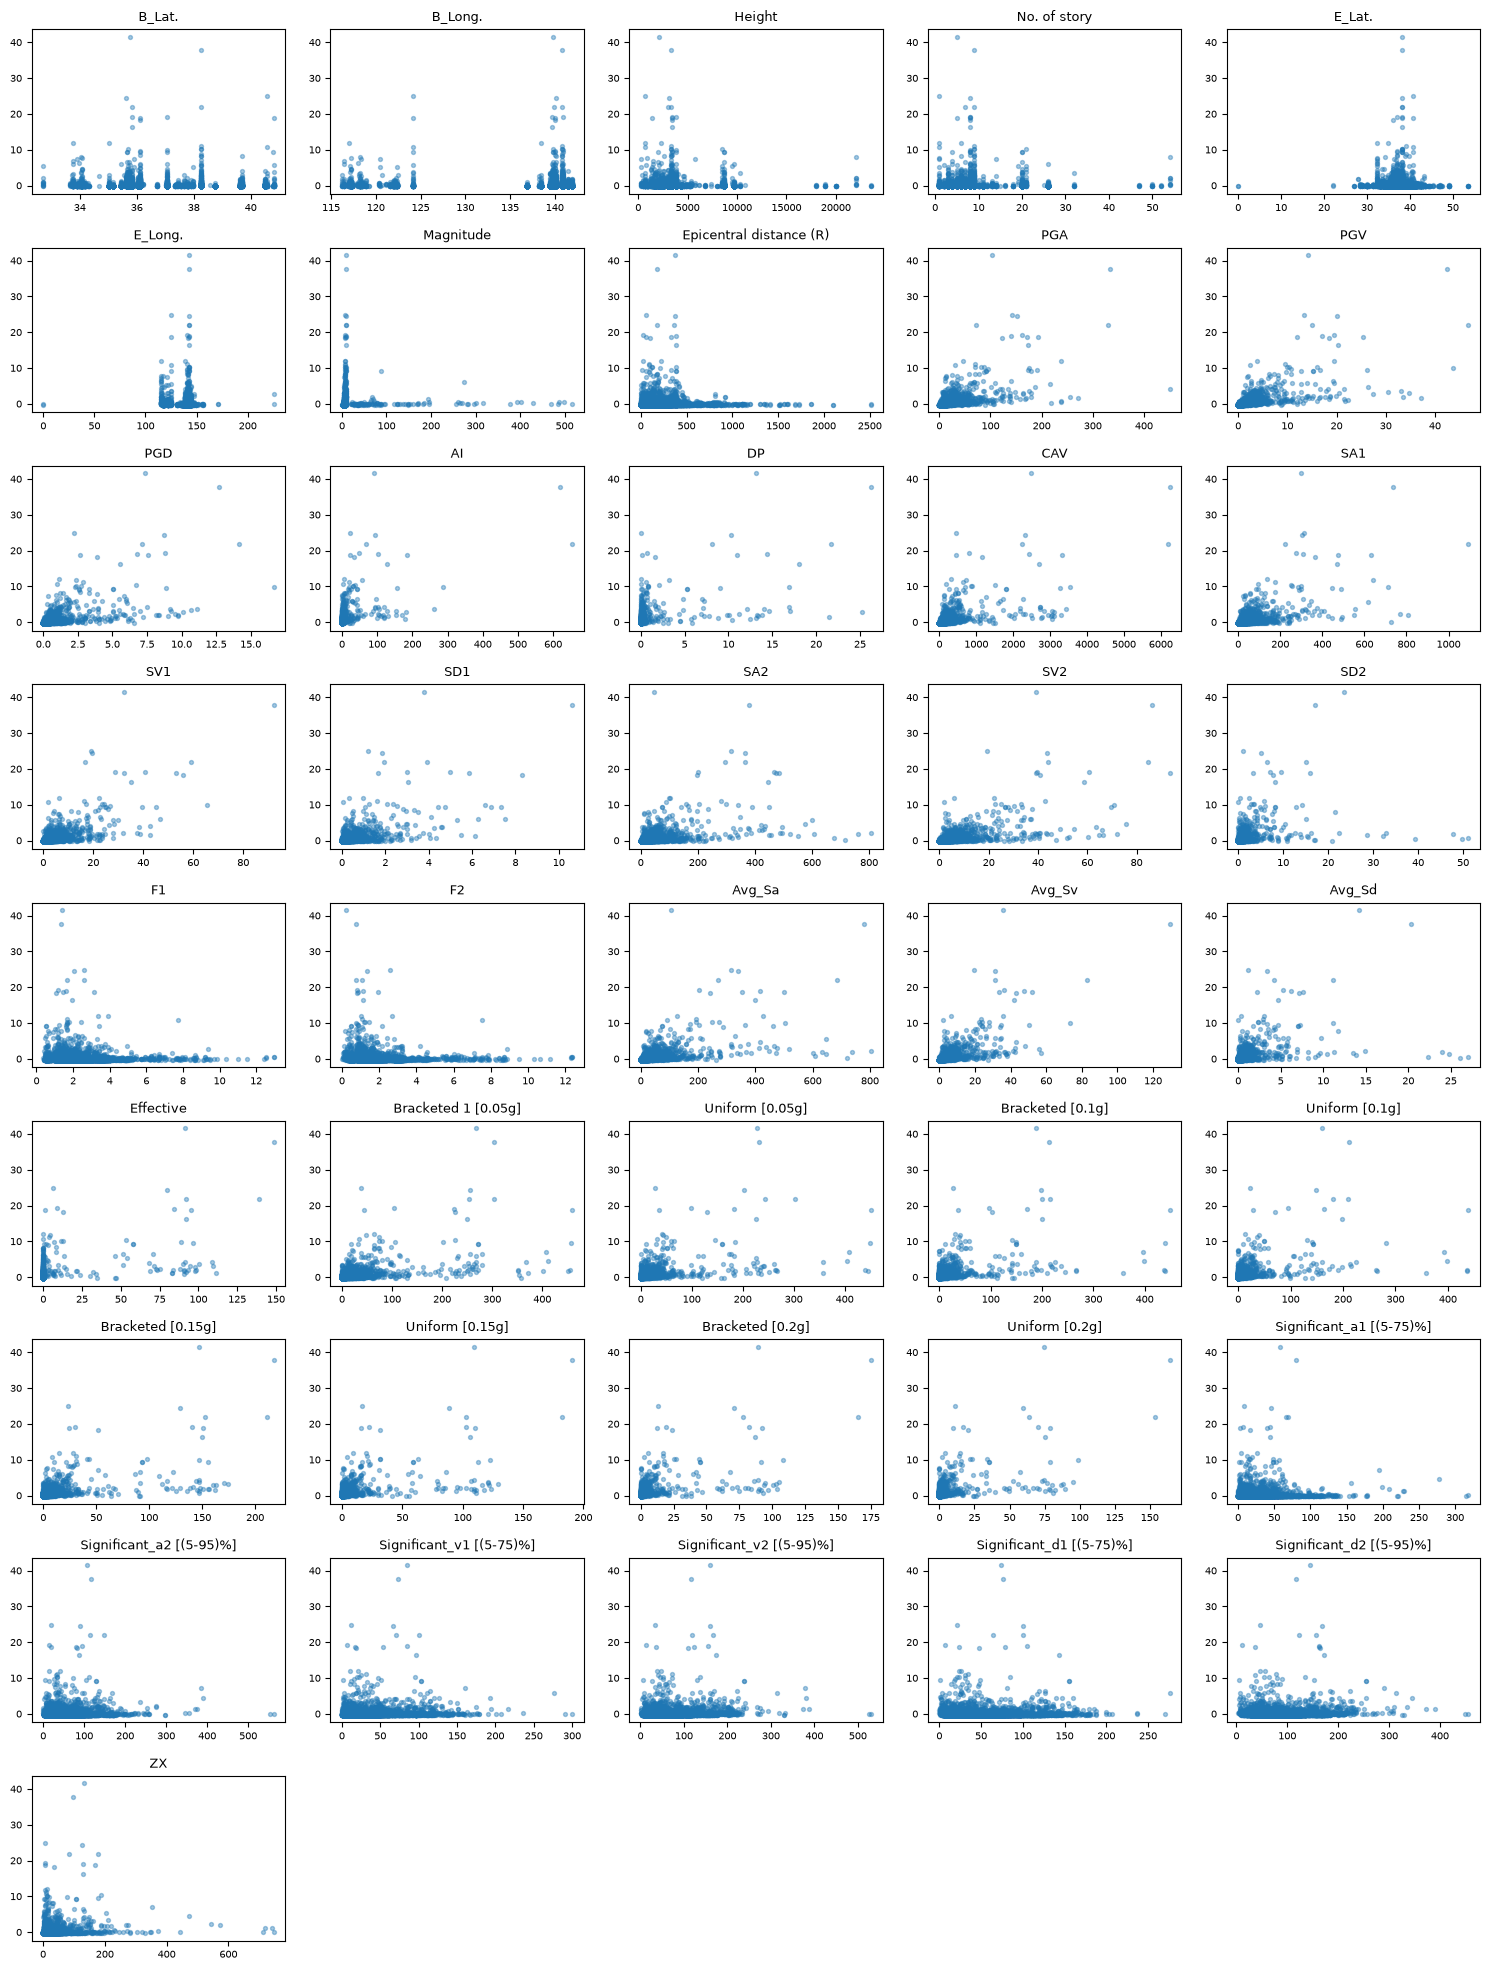

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

plt.figure(figsize=(4, 2.5))
sns.histplot(df['Drift'], kde=True)
plt.show()

features = [c for c in df.columns if c != 'Drift']
n_cols = 5
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 2.2 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(features):
    axes[idx].scatter(df[col], df['Drift'], s=8, alpha=0.4)
    axes[idx].set_title(col, fontsize=9)
    axes[idx].tick_params(labelsize=7)

# Hide any empty subplots at the end
for ax in axes[len(features):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

c. Highlight any particular pattern you observe from the visualizations. Which input features seem potentially more influential in predicting Drift?

Looking at the visualizations, the target variable Drift is strongly right-skewed, with the vast majority of data points clustered near the bottom (closer to 0) and only a handful of rare, high-intensity events causing significant drift spikes. The input features that seem to be the most influential are the ground-motion intensity and spectral parameters, specifically PGA, PGV, PGD, CAV, SA1, and Avg_Sa. These features show a positive, fan shaped trend and higher intensity values correspond to higher upper bounds on building drift.

## 3. Fit and evaluate (30 points)

a. Fit and evaluate a predictive framework using an SVR model. The process should include automatic tuning of both the kernel and the penalty parameter ((C)). Tune the hyperparameters using cross-validation on the training set, and evaluate the final predictive framework on a separate reporting set. Evaluate its performance using at least the Coefficient of Determination ($R^2$) and Mean Squared Error (MSE).

*N.B.* Remember that a predictive framework may involve more than just the predictive algorithm itself. Consider whether the characteristics of the predictors require any additional steps before fitting the model.

In [6]:
import numpy as np 
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

X = df.drop(columns='Drift')
y = df['Drift']

X_train, X_report, y_train, y_report = train_test_split(
    X, y, test_size=0.2, random_state=42
)

svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__kernel': ['linear', 'rbf'],
    'svr__C': [0.1, 1, 10]
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    svr_pipeline,
    param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    verbose=3
)

grid_search.fit(X_train, y_train)

best_svr = grid_search.best_estimator_
y_pred = best_svr.predict(X_report)

r2 = r2_score(y_report, y_pred)
mse = mean_squared_error(y_report, y_pred)

print("R²:", r2)
print("MSE:", mse)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ...svr__C=0.1, svr__kernel=linear;, score=-0.752 total time=   1.0s
[CV 2/5] END ...svr__C=0.1, svr__kernel=linear;, score=-0.512 total time=   0.8s
[CV 3/5] END ...svr__C=0.1, svr__kernel=linear;, score=-0.381 total time=   0.8s
[CV 4/5] END ...svr__C=0.1, svr__kernel=linear;, score=-1.223 total time=   0.9s
[CV 5/5] END ...svr__C=0.1, svr__kernel=linear;, score=-0.235 total time=   0.9s
[CV 1/5] END ......svr__C=0.1, svr__kernel=rbf;, score=-0.841 total time=   0.4s
[CV 2/5] END ......svr__C=0.1, svr__kernel=rbf;, score=-1.380 total time=   0.4s
[CV 3/5] END ......svr__C=0.1, svr__kernel=rbf;, score=-0.515 total time=   0.4s
[CV 4/5] END ......svr__C=0.1, svr__kernel=rbf;, score=-1.806 total time=   0.4s
[CV 5/5] END ......svr__C=0.1, svr__kernel=rbf;, score=-0.269 total time=   0.5s
[CV 1/5] END .....svr__C=1, svr__kernel=linear;, score=-0.755 total time=   4.3s
[CV 2/5] END .....svr__C=1, svr__kernel=linear;, 

b. Repeat the previous process using an Ridge regression predictive framework. Be sure to include automatic tuning of the model's hyperparameters, specifically, `alpha`.

In [23]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    verbose=3
)

grid_search_ridge.fit(X_train, y_train)

best_ridge = grid_search_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_report)

r2_ridge = r2_score(y_report, y_pred_ridge)
mse_ridge = mean_squared_error(y_report, y_pred_ridge)

print("R²:", r2_ridge)
print("MSE:", mse_ridge)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV 1/5] END ................ridge__alpha=0.01;, score=-0.778 total time=   0.1s
[CV 2/5] END ................ridge__alpha=0.01;, score=-0.692 total time=   0.0s
[CV 3/5] END ................ridge__alpha=0.01;, score=-0.431 total time=   0.0s
[CV 4/5] END ................ridge__alpha=0.01;, score=-1.147 total time=   0.0s
[CV 5/5] END ................ridge__alpha=0.01;, score=-0.501 total time=   0.0s
[CV 1/5] END .................ridge__alpha=0.1;, score=-0.767 total time=   0.1s
[CV 2/5] END .................ridge__alpha=0.1;, score=-0.684 total time=   0.0s
[CV 3/5] END .................ridge__alpha=0.1;, score=-0.433 total time=   0.0s
[CV 4/5] END .................ridge__alpha=0.1;, score=-1.149 total time=   0.0s
[CV 5/5] END .................ridge__alpha=0.1;, score=-0.500 total time=   0.0s
[CV 1/5] END ...................ridge__alpha=1;, score=-0.748 total time=   0.0s
[CV 2/5] END ...................ridge__alpha=1;, 

c. Use predicted vs. true value scatterplots to compare the SVR and Ridge predictive frameworks. Embed performance metrics (e.g., R², MSE) in each plot.

Which predictive framework appears to perform better at this task?

Ridge performs better than SVR because it has a higher R^2 value (0.609 compared to 0.561) and a lower MSE (0.307 compared to 0.345). This shows that Ridge explains more of the variation in Drift, and that it has a lower prediction error on the reporting set.

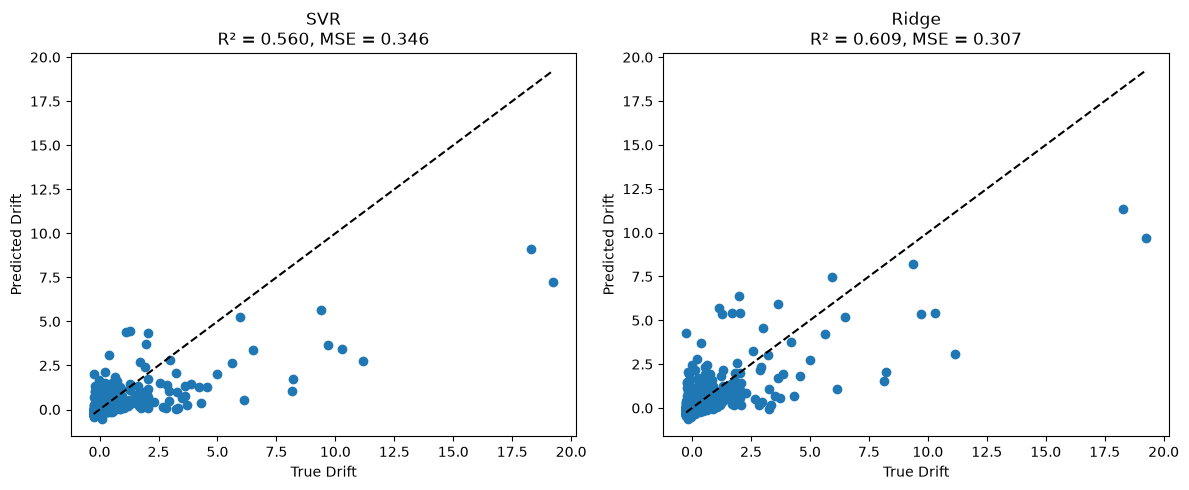

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_report, y_pred)
axes[0].plot(
    [y_report.min(), y_report.max()],
    [y_report.min(), y_report.max()],
    'k--'
)
axes[0].set_xlabel('True Drift')
axes[0].set_ylabel('Predicted Drift')
axes[0].set_title(f'SVR\nR² = {r2:.3f}, MSE = {mse:.3f}')

axes[1].scatter(y_report, y_pred_ridge)
axes[1].plot(
    [y_report.min(), y_report.max()],
    [y_report.min(), y_report.max()],
    'k--'
)
axes[1].set_xlabel('True Drift')
axes[1].set_ylabel('Predicted Drift')
axes[1].set_title(
    f'Ridge\nR² = {r2_ridge:.3f}, MSE = {mse_ridge:.3f}'
)

plt.tight_layout()
plt.show()

## 4. Reduced SVR Model (30 points)

a. Add a feature selection step to the SVR predictive framework that selects the 10 features most highly correlated with Drift. Retrain  this updated framework and evaluate its performance.

In [9]:
import numpy as np 
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop(columns='Drift')
y = df['Drift']

X_train, X_report, y_train, y_report = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reduced_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_regression, k=10)),
    ('svr', SVR())
])

param_grid = {
    'svr__kernel': ['linear', 'rbf'],
    'svr__C': [0.1, 1, 10]
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

reduced_grid_search = GridSearchCV(
    reduced_pipeline,
    param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    verbose=3
)

reduced_grid_search.fit(X_train, y_train)

best_reduced = reduced_grid_search.best_estimator_
y_pred = best_reduced.predict(X_report)

reduced_r2 = r2_score(y_report, y_pred)
reduced_mse = mean_squared_error(y_report, y_pred)

selected = best_reduced.named_steps['select'].get_support()
selected_features = X_train.columns[selected]

print("Selected features:", list(selected_features))
print("R²:", reduced_r2)
print("MSE:", reduced_mse)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ...svr__C=0.1, svr__kernel=linear;, score=-0.729 total time=   0.3s
[CV 2/5] END ...svr__C=0.1, svr__kernel=linear;, score=-0.778 total time=   0.3s
[CV 3/5] END ...svr__C=0.1, svr__kernel=linear;, score=-0.389 total time=   0.3s
[CV 4/5] END ...svr__C=0.1, svr__kernel=linear;, score=-1.302 total time=   0.3s
[CV 5/5] END ...svr__C=0.1, svr__kernel=linear;, score=-0.218 total time=   0.3s
[CV 1/5] END ......svr__C=0.1, svr__kernel=rbf;, score=-0.776 total time=   0.3s
[CV 2/5] END ......svr__C=0.1, svr__kernel=rbf;, score=-1.289 total time=   0.3s
[CV 3/5] END ......svr__C=0.1, svr__kernel=rbf;, score=-0.475 total time=   0.3s
[CV 4/5] END ......svr__C=0.1, svr__kernel=rbf;, score=-1.729 total time=   0.3s
[CV 5/5] END ......svr__C=0.1, svr__kernel=rbf;, score=-0.240 total time=   0.3s
[CV 1/5] END .....svr__C=1, svr__kernel=linear;, score=-0.728 total time=   0.6s
[CV 2/5] END .....svr__C=1, svr__kernel=linear;, 

Subsequently, answer the following questions:

- How much does the performance change?
- What are the practical advantages of using this predictive framework with a smaller subset of features?

Elaborate on your answers.

## Answer

### How much does the performance change?

Compared to the SVR trained on all features, the reduced SVR (top 10 features selected with `SelectKBest`) performs only slightly worse:

| Metric | Full SVR | Reduced SVR | Change |
|---|---|---|---|
| Test R² | 0.560 | 0.533 | ↓ ~5% |
| Test MSE | 0.346 | 0.367 | ↑ ~6% |
| Grid search time (30 fits) | ~186 s | ~22 s | ~8× faster |

Both models ran the same grid search: 5 folds × 2 kernels × 3 C values = 30 fits. Both also chose the same best hyperparameters (linear kernel, C = 0.1). The reduced model stays within roughly 5–6% of the full model on both accuracy metrics. The 10 selected features keep most of the predictive information in the dataset.

### What are the practical advantages of a smaller feature subset?

- **Computational efficiency:** The reduced model finished the grid search in about 22 seconds, compared with over 3 minutes for the full model. For a small loss in accuracy, the model trains far faster, which matters when retraining often or tuning over a larger grid.
- **Fewer inputs to collect:** Predicting drift only requires 10 ground-motion measures instead of the full set, so the model is cheaper and simpler to apply to new records.
- **Less noise and lower overfitting risk:** Dropping the features with the weakest relationship to drift removes inputs that add little signal, which can help the model generalize to new data.

Overall, the large gain in computational efficiency and simplicity outweighs the small decrease in accuracy, which makes the reduced model a practical choice.

b. Compare the performance of this reduced-feature SVR framework with an optimal Lasso regression framework that uses all available features.

- Do both frameworks select the same features?
- How do their performances compare?

In [10]:
from sklearn.linear_model import Lasso

X = df.drop(columns='Drift')
y = df['Drift']

X_train, X_report, y_train, y_report = train_test_split(X, y, test_size=0.2, random_state=42)

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

lasso_param_grid = {
    'lasso__alpha': np.logspace(-4, 1, 6)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

lasso_grid_search = GridSearchCV(
    lasso_pipeline,
    lasso_param_grid,
    cv=cv,
    scoring='neg_mean_squared_error',
    verbose=3
)

lasso_grid_search.fit(X_train, y_train)

best_lasso = lasso_grid_search.best_estimator_
best_alpha = lasso_grid_search.best_params_['lasso__alpha']

y_pred_lasso = best_lasso.predict(X_report)

lasso_r2 = r2_score(y_report, y_pred_lasso)
lasso_mse = mean_squared_error(y_report, y_pred_lasso)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/Users/maxguryan/Desktop/DS/DS4021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.269714e+02, tolerance: 8.647e-01
  model = cd_fast.enet_coordinate_descent(


[CV 1/5] END ..............lasso__alpha=0.0001;, score=-0.763 total time=   1.4s


/Users/maxguryan/Desktop/DS/DS4021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.497742e+02, tolerance: 7.590e-01
  model = cd_fast.enet_coordinate_descent(


[CV 2/5] END ..............lasso__alpha=0.0001;, score=-0.669 total time=   1.4s


...

[CV 3/5] END ..............lasso__alpha=0.0001;, score=-0.432 total time=   1.2s


/Users/maxguryan/Desktop/DS/DS4021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.629829e+00, tolerance: 6.784e-01
  model = cd_fast.enet_coordinate_descent(


[CV 4/5] END ..............lasso__alpha=0.0001;, score=-1.141 total time=   1.3s


/Users/maxguryan/Desktop/DS/DS4021/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.779217e+02, tolerance: 9.783e-01
  model = cd_fast.enet_coordinate_descent(


[CV 5/5] END ..............lasso__alpha=0.0001;, score=-0.497 total time=   1.2s
[CV 1/5] END ...............lasso__alpha=0.001;, score=-0.729 total time=   0.2s
[CV 2/5] END ...............lasso__alpha=0.001;, score=-0.650 total time=   0.1s
[CV 3/5] END ...............lasso__alpha=0.001;, score=-0.424 total time=   0.2s
[CV 4/5] END ...............lasso__alpha=0.001;, score=-1.117 total time=   0.2s
[CV 5/5] END ...............lasso__alpha=0.001;, score=-0.485 total time=   0.1s
[CV 1/5] END ................lasso__alpha=0.01;, score=-0.691 total time=   0.0s
[CV 2/5] END ................lasso__alpha=0.01;, score=-0.477 total time=   0.0s
[CV 3/5] END ................lasso__alpha=0.01;, score=-0.412 total time=   0.1s
[CV 4/5] END ................lasso__alpha=0.01;, score=-1.051 total time=   0.0s
[CV 5/5] END ................lasso__alpha=0.01;, score=-0.384 total time=   0.0s
[CV 1/5] END .................lasso__alpha=0.1;, score=-0.685 total time=   0.0s
[CV 2/5] END ...............

In [11]:
# Features being used by Lasso v.s. Reduced SVM

lasso_coefs = best_lasso.named_steps['lasso'].coef_
lasso_features = X_train.columns[lasso_coefs != 0]

reduced_features = list(X_train.columns[best_reduced['select'].get_support()])

print("Lasso kept", len(lasso_features), "features:")
print(list(lasso_features))

print("Reduced SVR kept", len(reduced_features), "features:")
print(list(reduced_features))

Lasso kept 7 features:
['PGD', 'AI', 'DP', 'CAV', 'SV1', 'SD1', 'Avg_Sv']
Reduced SVR kept 10 features:
['PGV', 'PGD', 'CAV', 'SA1', 'SV1', 'SD1', 'SV2', 'Avg_Sv', 'Bracketed [0.2g]', 'Uniform [0.2g]']


#### Do both frameworks select the same features?

No. Lasso selected 7 features, while the reduced SVR kept 10 (a number we set in the code). Of Lasso's 7 features, 5 are shared with the reduced SVR, and the other 2 (`AI` and `DP`) were selected only by the Lasso model.

The difference comes from how each method selects features. `SelectKBest` scores each feature individually by its linear relationship with drift and keeps the top 10. This means a Reduced SVR model can keep several highly correlated features that carry the same information. Lasso selects features jointly while fitting the model. It drops features that are redundant with ones already included and can keep features like `AI` and `DP` that are weak on their own but add new information in combination with the others.

In [12]:
# MSE and R2 compared Lasso v.s. Reduced SVM

print("Lasso Test R²: ", lasso_r2)
print("Lasso Test MSE:", lasso_mse)

print('\nReduced Test R²: ', reduced_r2)
print("Reduced Test MSE: ", reduced_mse)

Lasso Test R²:  0.6029867846798586
Lasso Test MSE: 0.3119994549512489

Reduced Test R²:  0.5329917140413107
Reduced Test MSE:  0.36700624829159434


#### How do their performances compare?

The lasso model was more efficient, only taking 7 seconds to complete the grid search compared to the Reduced SVR model's 22 seconds. Also, the Lasso model was able to outperform the Reduced SVR model with an increased R2 by 0.07 and a decreased MSE by 0.05, all while using fewer features. A majority of this increase performance can be attributed to the Lasso model avoiding the use of redundant variables. It is important to note that there are other computational differences that could also explain the increase performance of the lasso model, but our current explaination is most relevant to the topics discussed in this lab.

## 5: Robustness to Point Removal (10 points)

a. Compare the sensitivity of SVR and Ridge Regression predictive frameworks to small changes in the training set. To achieve this, randomly remove 10 training points, retrain both predictive frameworks, and assess how much the predictions change.

- Which predictive frameworks appears more stable?
- Why?

In [14]:
from sklearn.base import clone

np.random.seed(42)
remove_indices = np.random.choice(X_train.index, 10, replace=False)
X_train_reduced = X_train.drop(remove_indices)
y_train_reduced = y_train.drop(remove_indices)

print(f"Original training set size: {len(X_train)}")
print(f"Reduced training set size: {len(X_train_reduced)}")

Original training set size: 9532
Reduced training set size: 9522


In [15]:
# Retrain svr
retrained_svr = clone(best_svr)
retrained_svr.fit(X_train_reduced, y_train_reduced)

# Retrain ridge
retrained_ridge = clone(best_ridge)
retrained_ridge.fit(X_train_reduced, y_train_reduced)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](41,)","['B_Lat.','B_Long.','Height',...,'Significant_d1 [(5-75)%]', 'Significant_d2 [(5-95)%]','ZX']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,41
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [21]:
#svr
y_pred_svr_original = best_svr.predict(X_report)
y_pred_svr_retrained = retrained_svr.predict(X_report)
diff_svr = np.abs(y_pred_svr_original - y_pred_svr_retrained)
mean_diff_svr = np.mean(diff_svr)
max_diff_svr = np.max(diff_svr)

#ridge
y_pred_ridge_original = best_ridge.predict(X_report)
y_pred_ridge_retrained = retrained_ridge.predict(X_report)
diff_ridge = np.abs(y_pred_ridge_original - y_pred_ridge_retrained)
mean_diff_ridge = np.mean(diff_ridge)
max_diff_ridge = np.max(diff_ridge)

print(f"""\nSVR prediction differences after removing 10 points:\n  
Mean absolute difference: {mean_diff_svr:.4f}\n  
Max absolute difference: {max_diff_svr:.4f}\n"""
    )
print(f"""\nRidge prediction differences after removing 10 points:\n 
Mean absolute difference: {mean_diff_ridge:.4f}\n  
Max absolute difference: {max_diff_ridge:.4f}"""
    )


SVR prediction differences after removing 10 points:
  
Mean absolute difference: 0.0012
  
Max absolute difference: 0.1052


Ridge prediction differences after removing 10 points:
 
Mean absolute difference: 0.0001
  
Max absolute difference: 0.0042


#### Which predictive framework appears more stable?
Ridge regression

#### Why?
Ridge Regression is more stable because after removing the 10 training points, Ridge's mean absolute prediction difference is 0.0001 with a maximum change of only 0.0042, whereas SVR's mean absolute difference is 0.0012 (over 10 times higher) with a maximum change of 0.1052 (roughly 25 times higher). Ridge considers every single data point equally when fitting the line, so losing just 10 points out of roughly 9,500 barely makes a dent in the overall fit. SVR, on the other hand, depends heavily on a specific group of critical data points called support vectors to draw its boundary.

## 6. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

Our group did not encounter any major problems during this lab. As a group, we did a great job communicating with one another, equitably splitting up the tasks, staying on top of our agreed deadlines, and sharing feedback when needed. However, one aspect of our collaboration that could still be improved is where we get our work done. Most, if not all, of the work that we do is on our own time. Aside from the assigned time in-class, we have not met to get the lab done together. This is not a major problem because everyone has been contributing, but if your task for the lab is in the middle of the assignment, it becomes hard to know where to start without going through the code/responses provided before you. This makes each persons work largely more inefficient than the person before. Next time, we should do some more in-person work on the lab to ensure that everyone is on the same page. 